# **OBJECTIVE 3** :
***Improving Fleet Management & Operational Efficiency***

Automate PSV classification and tracking to support transport operators, fleet managers, optimizing maintenance schedules, and ensuring compliance with regulations. This system will help improve efficiency in the transport sector.

*Modeling Strategy:*

Deep Learning for Fleet Monitoring → Use CNN-based classification models to analyze PSV images for various fleet operators e.g matatu Saccos.

Other models used include pre trained MobileNet5

# **1. Import necessary Libraries and Load the data**

In [1]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
import os

In [3]:
from google.colab import drive
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tqdm import tqdm

In [6]:
#Mounting Google Drive to access data stored in the folders within the drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Define the dataset directory (same as Jupyter Notebook directory)
dataset_path = "/content/drive/MyDrive/Capstone_Project_Group1/Buses"


# Check if the dataset is accessible
print("Dataset contents:", os.listdir(dataset_path))

Dataset contents: ['Embassava', 'KBS_shuttle', 'City_shuttle', 'Super_metro', 'City_hopper']


# **2. Data Undertanding**
- Check the distribution of images
- Verify if there are any corrupted images
- Convert into a data frame for easy viewing of the dataset

In [ ]:
import os
# Define paths for each category

categories = {
    "KBS Shuttle": os.path.join(dataset_path, "KBS_shuttle"),
    "Embassava": os.path.join(dataset_path, "Embassava"),
    "Super Metro": os.path.join(dataset_path, "Super_metro"),
    "City Hopper": os.path.join(dataset_path, "City_hopper"),
    "City Shuttle": os.path.join(dataset_path, "City_shuttle"),

    }

# Verify files in each category
for category, path in categories.items():
    try:
        num_files = len(os.listdir(path))
        print(f"{category} Images: {num_files}")
    except FileNotFoundError:
        print(f"Warning: Path not found - {path}")
    except Exception as e:
        print(f"Error accessing {category}: {str(e)}")


KBS Shuttle Images: 31
Embassava Images: 29
Super Metro Images: 50
City Hopper Images: 50
City Shuttle Images: 30


In [ ]:
# Function to check for corrupted images in the Images Data folder (specifically files not in the correct format)
def check_image_validity(datafile_path, valid_extensions=('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
    """Checks for valid image files in a directory and its subdirectories.

    Args:
        dataset_path: The path to the root directory of your image dataset in Google Drive.
        valid_extensions: A tuple of valid image file extensions (case-insensitive).

    Returns:
        A dictionary where keys are category names (folder names) and values are lists of invalid image file paths within that category.  Also prints summary information.
    """

    invalid_images = {}
    total_images = 0
    corrupted_count = 0

    for root, _, files in os.walk(datafile_path):  # Walk through subdirectories
        category = os.path.basename(root)  # Get the category name (folder name)
        invalid_images[category] = []  # Initialize list for this category

        for filename in files:
            if filename.lower().endswith(valid_extensions): # Case-insensitive check
                filepath = os.path.join(root, filename)
                total_images += 1
                try:
                    img = Image.open(filepath)  # Or img = cv2.imread(filepath) for OpenCV
                    img.verify()  # Verify image integrity
                    img.close()
                except (IOError, SyntaxError) as e:  # Catch potential errors
                    print(f"Invalid image: {filepath} - {e}")
                    invalid_images[category].append(filepath)
                    corrupted_count += 1
            elif not filename.lower().endswith(valid_extensions):
                filepath = os.path.join(root, filename)
                print(f"Invalid file extension: {filepath}")
                invalid_images[category].append(filepath)


    print("\n--- Summary ---")
    print(f"Total images checked: {total_images}")
    print(f"Corrupted images found: {corrupted_count}")

    for category, invalid_files in invalid_images.items():
        if invalid_files:
            print(f"\nInvalid files in category '{category}':")
            for file in invalid_files:
                print(f"  - {file}")
        else:
            print(f"\nNo invalid files found in category '{category}'")

    return invalid_images


In [ ]:
# Check for invalid data types in our Image Dataset
invalid_images = check_image_validity(dataset_path)


--- Summary ---
Total images checked: 190
Corrupted images found: 0

No invalid files found in category 'Buses'

No invalid files found in category 'Embassava'

No invalid files found in category 'KBS_shuttle'

No invalid files found in category 'City_shuttle'

No invalid files found in category 'Super_metro'

No invalid files found in category 'City_hopper'


✅ Dataset loaded successfully!
                                               Image   Category
0  [[[180, 185, 189], [119, 124, 129], [73, 77, 8...  Embassava
1  [[[137, 157, 168], [146, 166, 177], [152, 172,...  Embassava
2  [[[252, 237, 218], [253, 238, 219], [253, 238,...  Embassava
3  [[[219, 220, 222], [220, 221, 223], [222, 223,...  Embassava
4  [[[133, 127, 115], [107, 101, 89], [109, 103, ...  Embassava


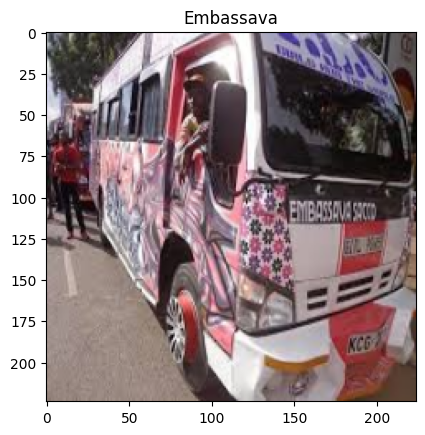

In [ ]:
# Define categories
categories = os.listdir(dataset_path)

# Store image data
data = []
labels = []

# Load images from each category folder
for category in categories:
    folder_path = os.path.join(dataset_path, category)

    if os.path.isdir(folder_path):  # Check if it's a folder
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)

            try:
                # Load image using OpenCV (BGR format)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

                # Resize image to (224x224) for consistency
                img = cv2.resize(img, (224, 224))

                # Append to lists
                data.append(img)
                labels.append(category)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

# Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Create a DataFrame for easy exploration
df = pd.DataFrame({"Image": list(data), "Category": labels})

print("✅ Dataset loaded successfully!")
print(df.head())  # Show first few rows

# Display an example image
plt.imshow(data[0])  # Show first image
plt.title(labels[0])  # Show category
plt.show()


In [ ]:
#Check the sample 5 images for each category
def display_images(df, num_images=5):
    categories = df["Category"].unique()  # Get unique categories from the DataFrame
    num_categories = len(categories)

    fig, axes = plt.subplots(num_categories, num_images, figsize=(15, 3 * num_categories))  # Adjust figure size dynamically

    for i, category in enumerate(categories):
        category_df = df[df["Category"] == category]

        if category_df.empty:  # Check if DataFrame is empty for this category
            print(f"No images found for category: {category}")
            continue  # Skip to the next category

        n_images_to_display = min(num_images, len(category_df)) # Ensure that it does not attempt to display more images than available for the category.
        category_images = category_df.sample(n_images_to_display)["Image"].values

        for j, img in enumerate(category_images):
            try:  # Handle potential issues with image display
                if num_categories == 1: # If only one category, axes is not an array, so we need to handle it differently
                    axes[j].imshow(img)
                    axes[j].axis("off")
                    if j == 0:
                        axes[j].set_title(category, fontsize=12)
                else: # If more than 1 category
                    axes[i, j].imshow(img)
                    axes[i, j].axis("off")
                    if j == 0:
                        axes[i, j].set_title(category, fontsize=12)
            except Exception as e:
                print(f"Error displaying image for {category}: {e}")

    plt.tight_layout()
    plt.show()

# Example usage (assuming you have a DataFrame 'df' with 'Category' and 'Image' columns):
display_images(df)

Output hidden; open in https://colab.research.google.com to view.

<ipython-input-76-0de7743d8d27>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


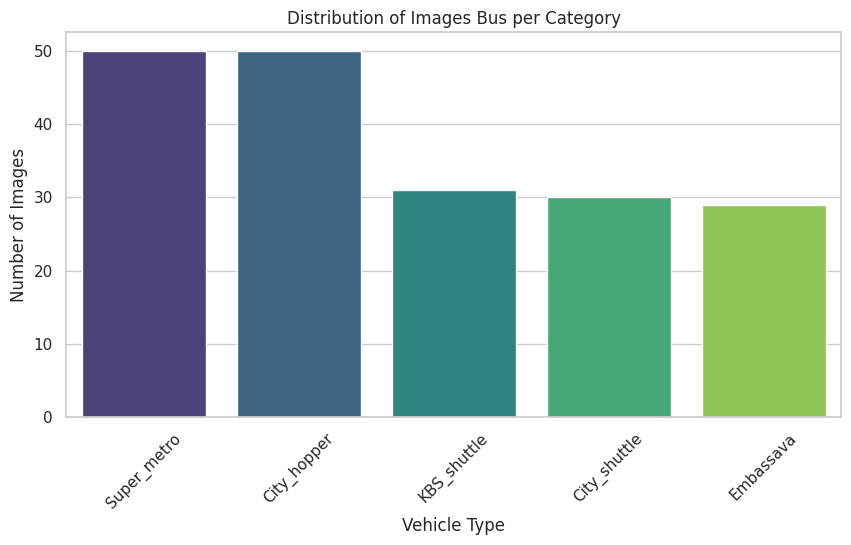

In [ ]:
# Plot destribution of images per category
# Count images per category
category_counts = df["Category"].value_counts()

# Plot distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Images Bus per Category")
plt.xticks(rotation=45)
plt.show();

<ipython-input-14-74d98f8fa79c>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.catplot(


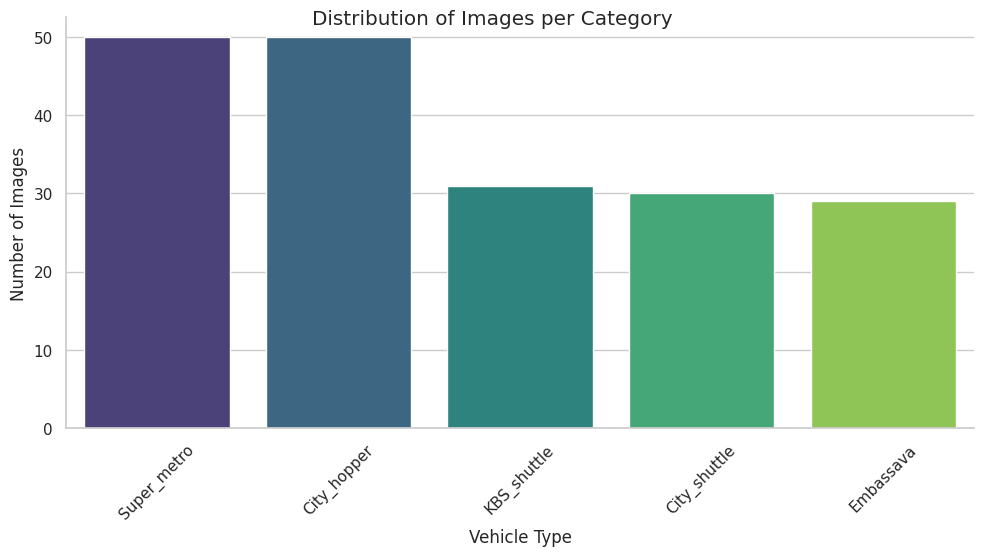

In [ ]:
# Count images per category
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Vehicle Type', 'Number of Images']

# Plot distribution using Seaborn
sns.set_theme(style="whitegrid")
ax = sns.catplot(
    data=category_counts,
    kind="bar",
    x="Vehicle Type",
    y="Number of Images",
    palette="viridis",
    height=5,
    aspect=2
)
ax.set_axis_labels("Vehicle Type", "Number of Images")
ax.fig.suptitle("Distribution of Images Bus per Category")

# Rotate x-axis labels
ax.set_xticklabels(rotation=45)

# Show the plot
sns.despine()
plt.show();

# **3. Data cleaning and Preprocessing**
- Standardize the dataset
- split the data set ( Train, Validation and Test Split)

**Scale Data**

**Standardizing Images for Better Performance**
To help our model learn better, we need to **normalize** the images.

- **Why?**: Images have pixel values from **0 to 255**, but we scale them to **0 to 1** for faster and more accurate learning.
- **How?**: We divide each pixel value by **255**.


In [ ]:
# Normalize pixel values to [0, 1]
df["Image"] = df["Image"].apply(lambda img: img / 255.0)

**Splitting the Dataset**

Now that our data is ready, we split it into three parts:

- **Training Set (70%)**: This is what the model will learn from.
- **Validation Set (15%)**: We use this to tune the model and make sure it’s not overfitting.
- **Test Set (15%)**: This is the final set to check how well the model performs after training.

We made sure each category is represented in all sets by using **stratified splitting**, which helps keep the balance and gives the model a fair chance to learn properly.


In [ ]:
#Splitting the data
# Define split ratios
train_ratio = 0.7  # 70% for training
val_ratio = 0.15   # 15% for validation
test_ratio = 0.15  # 15% for testing

# First, split into train and temp (val + test)
train_df, temp_df = train_test_split(df, test_size=(val_ratio + test_ratio), random_state=42, stratify=df["Category"])

# Then, split temp into validation and test
val_df, test_df = train_test_split(temp_df, test_size=test_ratio / (test_ratio + val_ratio), random_state=42, stratify=temp_df["Category"])

# Print dataset sizes
print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

Train set: 133 samples
Validation set: 28 samples
Test set: 29 samples


**After splitting the data into training, validation, and test sets:**


This code prepares image and label data for training a machine learning model
  by performing the following steps:

***Image Conversion and Reshaping:***
It converts the image data from DataFrame columns into NumPy arrays and reshapes them into a 4D format suitable for deep learning models (number of samples, height, width, channels).

***Label Conversion:***
The categorical labels are also converted from DataFrame columns into NumPy arrays.

**Label Encoding:**
A label encoder transforms the categorical labels into numerical format. The encoder is fitted on the training data and then applied to the validation and test data to maintain consistency.

***Verification:***
Finally, it prints the shapes of the resulting image and label arrays to confirm that the data is correctly formatted.

In [ ]:
# Convert 'Image' column to NumPy arrays
X_train = np.array(train_df["Image"].tolist()).reshape(-1, 224, 224, 3)
X_val = np.array(val_df["Image"].tolist()).reshape(-1, 224, 224, 3)
X_test = np.array(test_df["Image"].tolist()).reshape(-1, 224, 224, 3)

# Convert labels to NumPy arrays
y_train = np.array(train_df["Category"])
y_val   = np.array(val_df["Category"])
y_test  = np.array(test_df["Category"])

# Label encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded   = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test)

# Print shapes for confirmation
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (133, 224, 224, 3), y_train shape: (133,)
X_val shape: (28, 224, 224, 3), y_val shape: (28,)
X_test shape: (29, 224, 224, 3), y_test shape: (29,)


In [ ]:
# Number of classes
num_classes = len(np.unique(y_train_encoded))
print(f"Number of classes: {num_classes}")

Number of classes: 5


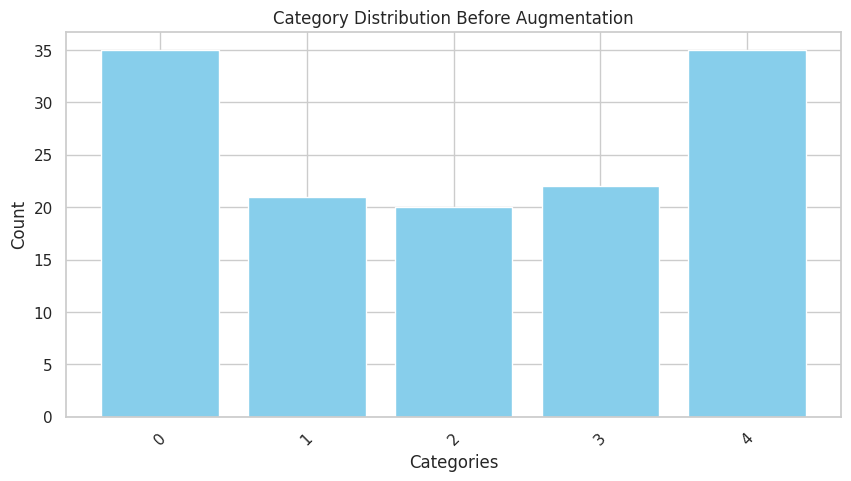

In [ ]:
# Plot disrtibution after label encoding and before argumentation
def plot_category_distribution(y_labels, title):
    counter = Counter(y_labels)
    categories = list(counter.keys())
    counts = list(counter.values())

    plt.figure(figsize=(10, 5))
    plt.bar(categories, counts, color='skyblue')
    plt.xlabel("Categories")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

# Plot category distribution before augmentation
plot_category_distribution(y_train_encoded, "Category Distribution Before Augmentation")


**Data Augmentation**

This code sets up two image augmentation pipelines and applies them to the training data based on category-specific configurations.

- **Augmentation Pipelines:**  
  Two pipelines are defined using an image augmentation library.  
  - The **color-sensitive pipeline** applies moderate color adjustments (minimal changes in brightness, contrast, hue, and saturation) along with common geometric transformations like horizontal flipping, shifting, scaling, rotating, and various distortion techniques.  
  - The **color-flexible pipeline** allows for more aggressive color modifications (increased limits on brightness, contrast, hue, saturation, and even RGB shifts) while applying similar geometric transformations.

- **Augmentation Configuration:**  
  A dictionary specifies the number of augmentations to apply for each category and indicates whether to use the color-sensitive or color-flexible pipeline.

- **Augmentation Process:**  
  The `augment_training_data` function:
  - Ensures that images are in the correct format (uint8) for the augmentation library.
  - Iterates over each training image and its corresponding label.
  - Adds the original image to the augmented dataset.
  - Determines the category of the image (using a label encoder) and selects the appropriate pipeline based on the configuration.
  - Generates a specified number of augmented images per category using the chosen pipeline.
  - Converts the final augmented images back to a normalized format ([0, 1] float32) and returns both the augmented images and labels.


In [ ]:
def create_color_sensitive_pipeline():
    """Augmentation pipeline that preserves color characteristics"""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.8),
        # Minimal color adjustments
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
        A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.3),
        # Geometric and texture variations
        A.OneOf([
            A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=0.5),
        ], p=0.3),
    ])

def create_color_flexible_pipeline():
    """Augmentation pipeline that can modify colors more aggressively"""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.8),
        # Aggressive color augmentations
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
        A.HueSaturationValue(hue_shift_limit=30, sat_shift_limit=50, val_shift_limit=30, p=0.7),
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.5),
        # Geometric and texture variations
        A.OneOf([
            A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=0.5),
        ], p=0.3),
    ])

# Example config: how many augmentations per category
augmentation_config = {
    "KBS_shuttle":         {"count": 22, "color_sensitive": True},
    "Embassava":           {"count": 24, "color_sensitive": True},
    "Super_metro":         {"count": 15, "color_sensitive": True},
    "City_hopper":         {"count": 15, "color_sensitive": True},
    "City_shuttle":        {"count": 24, "color_sensitive": True},
   }

def augment_training_data(X_train, y_train, augmentation_config):
    """
    Perform augmentation on X_train, y_train using category-specific strategies.
    For sparse_categorical_crossentropy, labels remain integer-encoded.
    """
    # Ensure images are uint8 for Albumentations
    if X_train.dtype != np.uint8:
        X_train = (X_train * 255).astype(np.uint8)

    color_sensitive_pipeline = create_color_sensitive_pipeline()
    color_flexible_pipeline  = create_color_flexible_pipeline()

    X_augmented_list = []
    y_augmented_list = []

    # Convert integer label back to string for augmentation_config
    # Then convert to integer label again after augmentation
    for image, label_int in tqdm(zip(X_train, y_train), total=len(X_train), desc="Augmenting images"):
        # Original image
        X_augmented_list.append(image)
        y_augmented_list.append(label_int)

        # Map integer label -> string category
        label_str = label_encoder.inverse_transform([label_int])[0]

        # Choose augmentation config
        category_config = augmentation_config.get(label_str, {"count": 0, "color_sensitive": False})
        pipeline = color_sensitive_pipeline if category_config["color_sensitive"] else color_flexible_pipeline

        # Perform augmentations
        for _ in range(category_config["count"]):
            transformed = pipeline(image=image)
            X_augmented_list.append(transformed["image"])
            y_augmented_list.append(label_int)

    # Convert back to float32 in [0,1]
    X_augmented_final = np.array(X_augmented_list).astype('float32') / 255.0
    y_augmented_final = np.array(y_augmented_list)

    return X_augmented_final, y_augmented_final


In [ ]:
# Run augmentation
# Actually augment the training set
X_train_augmented, y_train_augmented = augment_training_data(X_train, y_train_encoded, augmentation_config)

print("Augmentation complete.")
print("X_train_augmented shape:", X_train_augmented.shape)
print("y_train_augmented shape:", y_train_augmented.shape)



/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
<ipython-input-20-1273e0aee45c>:11: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
<ipython-input-20-1273e0aee45c>:13: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=0.5),
<ipython-input-20-1273e0aee45c>:28: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
<ipython-input-20-1273e0aee45c>:30: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=0.

Augmentation complete.
X_train_augmented shape: (2651, 224, 224, 3)
y_train_augmented shape: (2651,)


In [ ]:
# Convert to NumPy arrays
data_check = X_train_augmented
label_check = y_train_augmented

# Create a DataFrame for easy exploration
df_2 = pd.DataFrame({"Image": list(data_check), "Category": label_check})

print("✅ Dataset loaded successfully!")
print(df_2.head())  # Show first few rows

✅ Dataset loaded successfully!
                                               Image  Category
0  [[[0.93333334, 0.9411765, 0.92941177], [0.9333...         0
1  [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...         0
2  [[[0.007843138, 0.003921569, 0.003921569], [0....         0
3  [[[0.93333334, 0.9411765, 0.92941177], [0.9333...         0
4  [[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...         0


In [ ]:
# Displaying the images after augumentation
def display_images(df_2, num_images=5):
    categories = df_2["Category"].unique()  # Get unique categories from the DataFrame
    num_categories = len(categories)

    fig, axes = plt.subplots(num_categories, num_images, figsize=(15, 3 * num_categories))  # Adjust figure size dynamically

    for i, category in enumerate(categories):
        category_df_2 = df_2[df_2["Category"] == category]

        if category_df_2.empty:  # Check if DataFrame is empty for this category
            print(f"No images found for category: {category}")
            continue  # Skip to the next category

        n_images_to_display = min(num_images, len(category_df_2)) # Ensure that it does not attempt to display more images than available for the category.
        category_images = category_df_2.sample(n_images_to_display)["Image"].values

        for j, img in enumerate(category_images):
            try:  # Handle potential issues with image display
                if num_categories == 1: # If only one category, axes is not an array, so we need to handle it differently
                    axes[j].imshow(img)
                    axes[j].axis("off")
                    if j == 0:
                        axes[j].set_title(category, fontsize=12)
                else: # If more than 1 category
                    axes[i, j].imshow(img)
                    axes[i, j].axis("off")
                    if j == 0:
                        axes[i, j].set_title(category, fontsize=12)
            except Exception as e:
                print(f"Error displaying image for {category}: {e}")

    plt.tight_layout()
    plt.show()

# Example usage (assuming you have a DataFrame 'df' with 'Category' and 'Image' columns):
display_images(df_2)

Output hidden; open in https://colab.research.google.com to view.

<ipython-input-77-e1abd87b3044>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_category_distribution, x='Encoded_Label', y='Count', palette="viridis")  # Greenish-yellow gradient


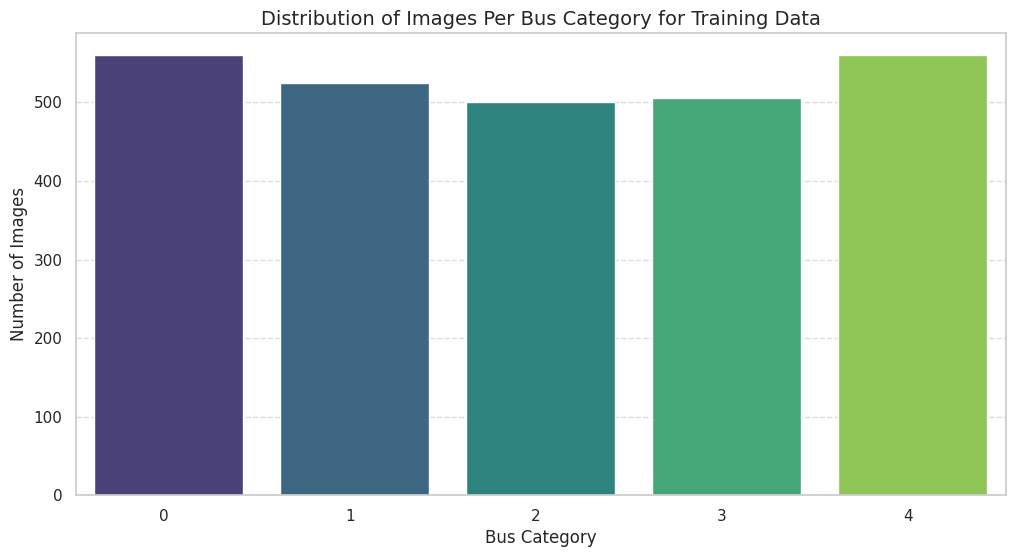

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Count occurrences of each encoded label
category_counts = Counter(y_train_augmented)

# Convert to DataFrame for better visualization
df_category_distribution = pd.DataFrame(list(category_counts.items()), columns=['Encoded_Label', 'Count'])

# Set the figure size and style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a bar plot
sns.barplot(data=df_category_distribution, x='Encoded_Label', y='Count', palette="viridis")  # Greenish-yellow gradient

# Customize the plot
plt.xticks(rotation=0, ha="right")
plt.xlabel("Bus Category", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Images Per Bus Category for Training Data", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()


# **Insights : Data Cleaning and Data Agumentation**

From the above work done it is noted that there is now more diversity in the images after agumentation and that the number of images have increased in the training data in order for the model to perform better.

The images also are clear and visible even after agumentation.

# **4. Exploratory Data Analysis - EDA**

**Image Dimentions**

The code bellow allows us to examines the dimensions of images within a dataset and visualizes their width and height distributions:

***Collecting Image Dimensions:***
It iterates through a sample of 100 images per category, opening each image with the PIL library and recording its size (width and height).

***Data Preparation:***
The collected image sizes are converted into a NumPy array for efficient numerical processing.

***Visualization:***
Two histograms are plotted using Matplotlib:

One histogram displays the distribution of image widths.
The other shows the distribution of image heights.
This process helps in understanding the range of dimensions and aspect ratios present in the dataset.


Text(0.5, 1.0, 'Image Height Distribution')

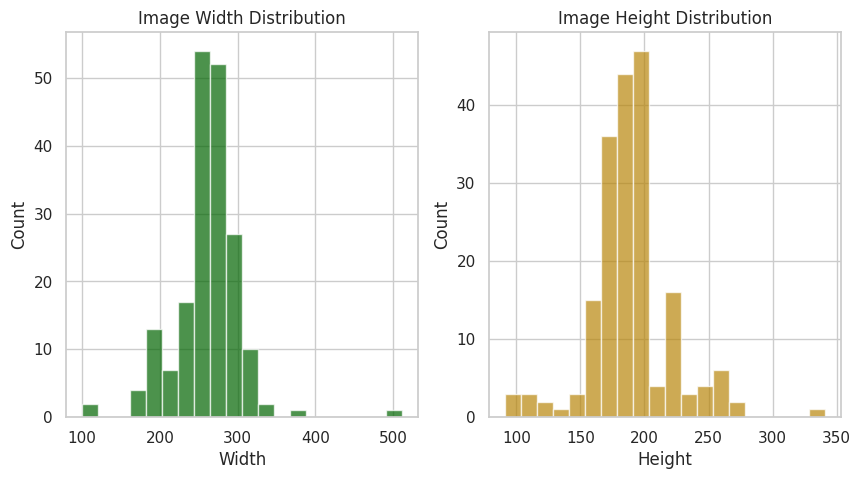

In [ ]:
#Check image dimensions and aspect ratio

from PIL import Image
import numpy as np

image_sizes = []
for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path)[:100]:  # Sample 100 images
        img = Image.open(os.path.join(category_path, img_name))
        image_sizes.append(img.size)  # (width, height)

# Convert to numpy array
image_sizes = np.array(image_sizes)

# Plot histogram of widths & heights
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(image_sizes[:,0], bins=20, color='darkgreen', alpha=0.7)
plt.xlabel("Width")
plt.ylabel("Count")
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
plt.hist(image_sizes[:,1], bins=20, color='darkgoldenrod', alpha=0.7)
plt.xlabel("Height")
plt.ylabel("Count")
plt.title("Image Height Distribution")

**Image Brightness**

The code below evaluates the brightness of images in a dataset and visualizes the brightness distribution:

- **Image Reading and Conversion:**  
  The code iterates through a sample of 100 images per category, reading each image in grayscale using OpenCV. Converting images to grayscale simplifies the brightness analysis by reducing them to single-channel images.

- **Brightness Calculation:**  
  For each grayscale image, the mean pixel value is calculated, representing its average brightness.

- **Visualization:**  
  A histogram is plotted using Matplotlib to display the distribution of brightness levels across the sampled images, helping to understand the overall exposure characteristics of the dataset.

---



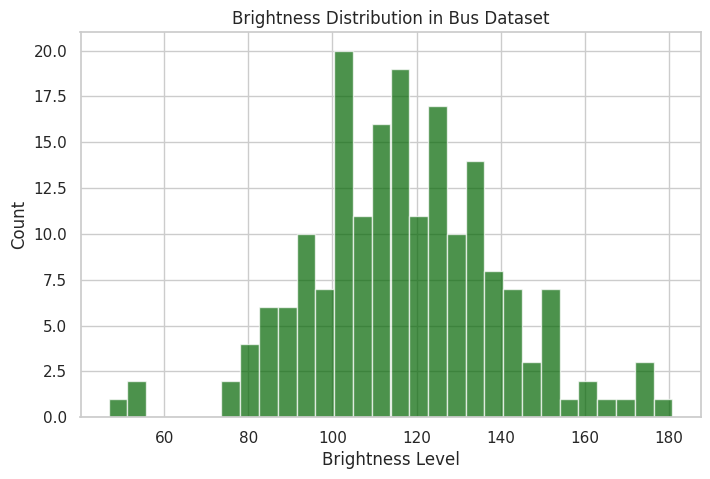

In [ ]:
# Check image brightness

import cv2
import numpy as np

brightness_values = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path)[:100]:  # Sample 100 images
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
        brightness_values.append(np.mean(img))  # Compute mean brightness

# Plot brightness histogram
plt.figure(figsize=(8,5))
plt.hist(brightness_values, bins=30, color='darkgreen', alpha=0.7)
plt.xlabel("Brightness Level")
plt.ylabel("Count")
plt.title("Brightness Distribution in Bus Dataset")
plt.show()

# **Insights : Exploratory Data Analysis**

**Image Dimensions**

1. **Image Width Distribution (Blue)**
   - The majority of images have widths clustered around **250-300 pixels**.
   - A few outliers have widths either significantly smaller (~100 pixels) or larger (~400+ pixels).
   - The peak frequency is around **270-280 pixels**, suggesting this is the most common image width.

2. **Image Height Distribution (Red)**
   - Most images have heights around **170-200 pixels**.
   - There are a few images with significantly smaller or larger heights (~100 or 300 pixels).
   - The highest frequency occurs near **190 pixels**, meaning this is the dominant height among images.

### **observations:**
- The images in the dataset mostly fall within a compact range of dimensions.
- There is a strong concentration around **specific width and height values**, indicating that images likely come from a structured source with consistent sizing.
- Some variability exists, but extreme values are rare.

**Image Brightness**

1. **Distribution Shape:**
   - The histogram appears **roughly normal (bell-shaped)** but slightly skewed to the right.
   - Most brightness values fall between **80 and 140**.
   - The highest frequency occurs around **100-120**, indicating that the majority of images have brightness levels within this range.

2. **Peak and Frequency:**
   - The peak of the distribution (mode) is near **100-120 brightness level**, suggesting that this is the most common brightness range in the dataset.
   - A few images have significantly lower brightness (around **50-70**) or higher brightness (above **150**), but these are much less frequent.

3. **Outliers and Spread:**
   - Some images have very low brightness (<70) and very high brightness (>160), indicating **a small number of extremely dark or bright images**.
   - The spread suggests a **moderate variation in brightness** across the dataset, but most images cluster in the central range.

### **observations:**
- **Most images have balanced brightness**, with a slight tendency towards lower values.
- **A few outliers** suggest there are some very dark or very bright images in the dataset.
- If **image preprocessing is required**, consider normalizing brightness values to improve uniformity.

Would you like to explore contrast distribution or check if brightness normalization is needed?


# **Modelling**

- **Baseline CNN Model:**  
  A simple CNN with three convolutional layers, pooling, and dense layers that establishes a performance benchmark by extracting fundamental visual features.

- **Improved CNN Model:**  
  An enhanced version that incorporates dropout, L2 regularization, learning rate scheduling, and class weighting to mitigate overfitting and handle class imbalances, resulting in a more robust model.

- **Pre-trained MobileNetV2 Model:**  
  A transfer learning approach using a pre-trained MobileNetV2 that applies learned features from large-scale datasets to achieve faster convergence and improved accuracy with limited data(images).

- **EfficientNetV2 Model:**  
  An architecture that uses compound scaling to optimize depth, width, and resolution simultaneously. This model delivers high accuracy while maintaining computational efficiency, making it an excellent choice for complex image classification tasks.


**Model 1 : Baseline CNN model**

Below is the baseline CNN model used for bus fleet category image classification. This model consists of three convolutional layers with increasing filter sizes, followed by pooling layers, a flattening step, and two dense layers (the final one using softmax activation for classification across 5 classes).

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define a baseline CNN model
model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # Output layer
])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Print model summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile with a standard learning rate and SGD optimizer
model_1.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),  # Standard learning rate for a baseline model
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Basic Data Augmentation (Moderate Augmentations for Baseline)
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Convert dataset to `tf.data.Dataset`
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_augmented, y_train_augmented))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_encoded))
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# Early stopping callback (basic regularization)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
hist_1 = model_1.fit(
    train_dataset,
    epochs=20,  # Fewer epochs for a baseline model
    validation_data=val_dataset,
    callbacks=[early_stopping]
)



Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 198ms/step - accuracy: 0.2846 - loss: 1.5650 - val_accuracy: 0.4643 - val_loss: 1.4726
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.5019 - loss: 1.2709 - val_accuracy: 0.4286 - val_loss: 1.1485
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6058 - loss: 0.9810 - val_accuracy: 0.8571 - val_loss: 0.4089
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.8163 - loss: 0.5020 - val_accuracy: 0.8929 - val_loss: 0.3104
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.8544 - loss: 0.3790 - val_accuracy: 0.8929 - val_loss: 0.2878
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.9475 - loss: 0.1559 - val_accuracy: 0.9286 - val_loss: 0.1624
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9761 - loss: 0.0715 - val_accuracy: 0.8929 - val_loss: 0.3230
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9767 - loss: 0.0734 - val_accuracy: 0.8929 -

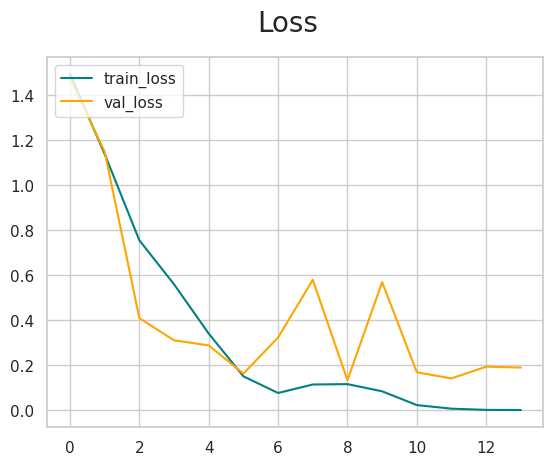

In [ ]:
#Plotting the training and validation loss
fig = plt.figure()
plt.plot(hist_1.history['loss'], color='teal', label='train_loss')
plt.plot(hist_1.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

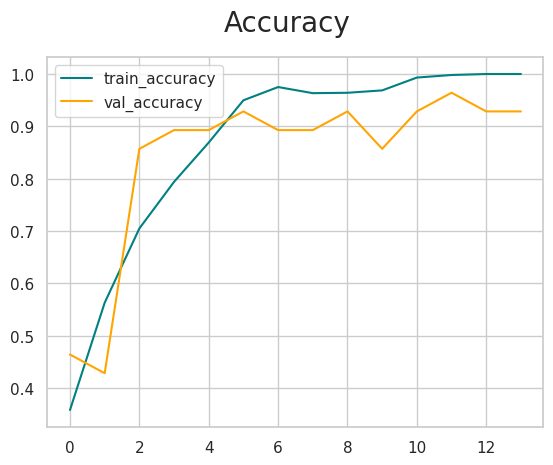

In [ ]:
#Plot the training and validation accuracy
fig = plt.figure()
plt.plot(hist_1.history['accuracy'], color='teal', label='train_accuracy')
plt.plot(hist_1.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         5
           2       1.00      0.60      0.75         5
           3       1.00      1.00      1.00         4
           4       0.78      1.00      0.88         7

    accuracy                           0.93        28
   macro avg       0.96      0.92      0.93        28
weighted avg       0.94      0.93      0.92        28

Confusion Matrix:


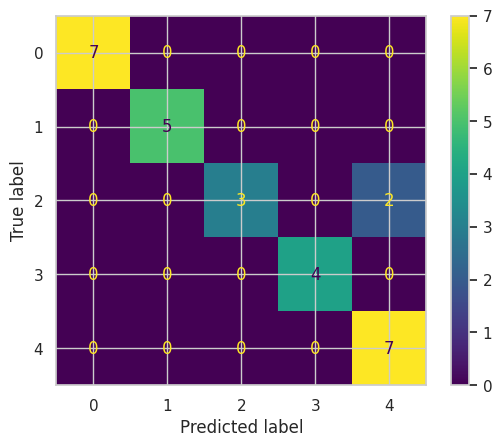

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Get model predictions (probabilities)
y_pred_probs = model_1.predict(X_val)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Predicted labels

# Generate classification report
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred_classes))

# Generate confusion matrix
print("Confusion Matrix:")
cnf_matrix =confusion_matrix(y_val_encoded, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix= cnf_matrix)
disp.plot();

In [ ]:
test_loss, test_accuracy = model_1.evaluate(X_test, y_test_encoded)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7931 - loss: 1.5566
Test Loss: 1.5566
Test Accuracy: 0.7931


**Summary of results for Baseline CNN Model**

***Accuracy of 93 %***

The model correctly classifies the majority of validation samples.

***Class Performance***

Perfect 100 % precision and recall for classes 0, 1, and 3.
Class 2: Precision is 1.00, but recall drops to 0.60 (it misses some true class-2 samples).
Class 4: Recalls all true samples (1.00) but occasionally misclassifies others as class 4 (precision 0.78).

***Training vs. Validation***

The model fits the training set almost perfectly, with validation accuracy stabilizing around the low 90s—slight overfitting is possible.



**Model 2 : Improved CNN Model**

This model, builds upon the baseline CNN by adding dropout, L2 regularization, learning rate scheduling, and class weighting.

These enhancements aim to reduce overfitting, handle class imbalances more effectively, and ultimately achieve better generalization compared to the simpler baseline approach.



In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# Define CNN model with Dropout and L2 Regularization
model_2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.01),
                  input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.01)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.01)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Print model summary
model_2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile with lower learning rate
model_2.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

# Convert to dictionary format required by Keras
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class Weights:", class_weights_dict)

# Define cosine annealing learning rate scheduler
def cosine_annealing(epoch, lr):
    return 0.001 * (0.5 * (1 + np.cos(np.pi * (epoch % 10) / 10)))

lr_scheduler = LearningRateScheduler(cosine_annealing)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Data Augmentation with stronger transformations
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

# Convert dataset to `tf.data.Dataset` for efficiency
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_augmented, y_train_augmented))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_encoded))
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# Train the model with class weights
hist_2 = model_2.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, early_stopping],
    class_weight=class_weights_dict
)

Class Weights: {0: 0.76, 1: 1.2666666666666666, 2: 1.33, 3: 1.209090909090909, 4: 0.76}
Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/step - accuracy: 0.1896 - loss: 5.6019 - val_accuracy: 0.2857 - val_loss: 5.4561 - learning_rate: 0.0010
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.2931 - loss: 5.4426 - val_accuracy: 0.2857 - val_loss: 5.3734 - learning_rate: 9.7553e-04
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.3196 - loss: 5.3176 - val_accuracy: 0.3929 - val_loss: 5.2846 - learning_rate: 9.0451e-04
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.3481 - loss: 5.2134 - val_accuracy: 0.3929 - val_loss: 5.2157 - learning_rate: 7.9389e-04
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.3709 - loss: 5.1108 - val_accuracy: 0.4643 - val_loss: 5.1459 - learning_rate: 6.5451e-04
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.4054 - loss: 5.0142 - val_accuracy: 0.3929 - val_loss: 5.0691 - learning_r

In [ ]:
test_loss, test_accuracy = model_2.evaluate(X_test, y_test_encoded)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step - accuracy: 0.6897 - loss: 3.8434
Test Loss: 3.8434
Test Accuracy: 0.6897


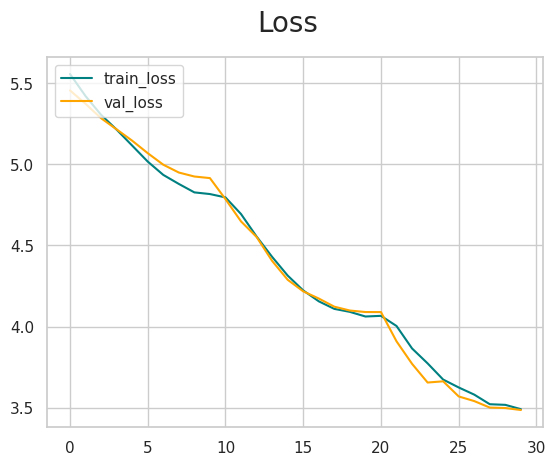

In [ ]:
#Plotting the training and validation loss
fig = plt.figure()
plt.plot(hist_2.history['loss'], color='teal', label='train_loss')
plt.plot(hist_2.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

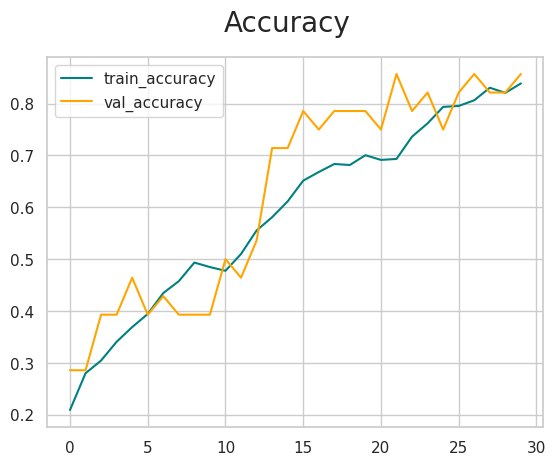

In [ ]:
#Plot the training and validation accuracy
fig = plt.figure()
plt.plot(hist_2.history['accuracy'], color='teal', label='train_accuracy')
plt.plot(hist_2.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.71      1.00      0.83         5
           2       1.00      0.60      0.75         5
           3       1.00      0.75      0.86         4
           4       0.78      1.00      0.88         7

    accuracy                           0.86        28
   macro avg       0.90      0.84      0.85        28
weighted avg       0.89      0.86      0.85        28

Confusion Matrix:


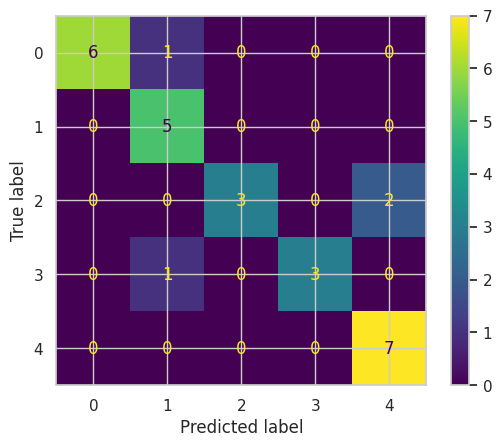

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Get model predictions (probabilities)
y_pred_probs = model_2.predict(X_val)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Predicted labels

# Generate classification report
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred_classes))

# Generate confusion matrix
print("Confusion Matrix:")
cnf_matrix =confusion_matrix(y_val_encoded, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix= cnf_matrix)
disp.plot();

**Summary of results for Improved CNN Model**

***Accuracy of 86%***

The model achieves an 86% accuracy on the validation set, showing a solid improvement approach compared to the baseline.

***Class Performance***

Class 0: Perfect precision (1.00) and 0.86 recall
Class 1: 0.71 precision, but 1.00 recall
Class 2: 1.00 precision, 0.60 recall (some misses)
Class 3: 1.00 precision, 0.75 recall
Class 4: 0.78 precision, 1.00 recall (some false positives)

***Training vs. Validation***

Training accuracy (~83%) remains close to validation accuracy (86%), indicating limited overfitting. However, the test accuracy (around 69%) suggests further tuning or additional data may be needed for stronger real-world performance.

**Model 3 : MobileNetV2**

This model is an improvement from the Improved CNN Model and applies a transfer learning strategy using a pre-trained MobileNetV2 architecture which by freezing the base layers and only training newly added classification layers, the model leverages learned features from large-scale datasets like ImageNet.

This approach typically gives better results with less training time.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load pre-trained MobileNetV2 without the top classification layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers to prevent training updates
base_model.trainable = False

# Define the new model architecture
model_3 = Sequential([
    base_model,  # Add the pre-trained base model
    GlobalAveragePooling2D(),  # Reduce the dimensionality of feature maps
    Dense(128, activation='relu'),  # Add a dense layer with 128 units and ReLU activation
    Dropout(0.5),  # Add a dropout layer for regularization
    Dense(num_classes, activation='softmax')  # Output layer with 4 units and softmax activation
])

# Compile the model with a learning rate and sparse categorical cross-entropy loss
model_3.compile(
    optimizer= SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',  # using integer-encoded labels
    metrics=['accuracy']
)


In [ ]:
# Train the model
hist_3 = model_3.fit(
    X_train_augmented,
    y_train_augmented,
    epochs=20,
    validation_data=(X_val, y_val_encoded),
    batch_size=32,
    #callbacks=[early_stopping]
)

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.2800 - loss: 1.7925 - val_accuracy: 0.4643 - val_loss: 1.2460
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5792 - loss: 1.0783 - val_accuracy: 0.7143 - val_loss: 0.9529
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7217 - loss: 0.8038 - val_accuracy: 0.8214 - val_loss: 0.8062
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7871 - loss: 0.6264 - val_accuracy: 0.8214 - val_loss: 0.7033
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8360 - loss: 0.5130 - val_accuracy: 0.8214 - val_loss: 0.6531
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8654 - loss: 0.4530 - val_accuracy: 0.8929 - val_loss: 0.5886
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8905 - loss: 0.3682 - val_accuracy: 0.8571 - val_loss: 0.5824
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9238 - loss: 0.3019 - val_accuracy: 0.8571 -

In [ ]:
test_loss, test_accuracy = model_3.evaluate(X_test, y_test_encoded)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7586 - loss: 0.8956
Test Loss: 0.8956
Test Accuracy: 0.7586


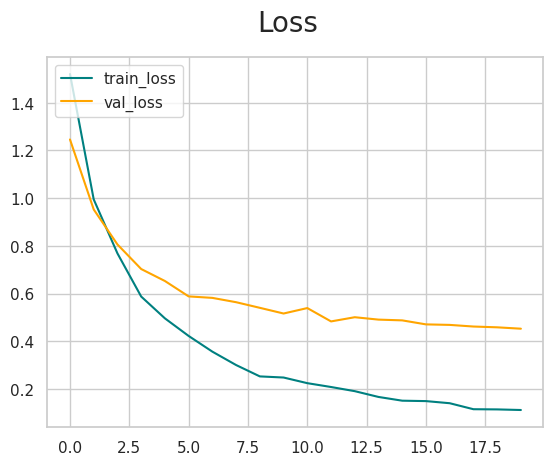

In [ ]:
#Plotting the training and validation loss
fig = plt.figure()
plt.plot(hist_3.history['loss'], color='teal', label='train_loss')
plt.plot(hist_3.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

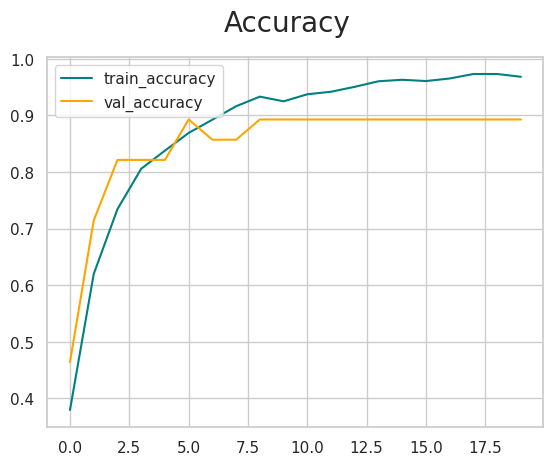

In [ ]:
#Plot the training and validation accuracy
fig = plt.figure()
plt.plot(hist_3.history['accuracy'], color='teal', label='train_accuracy')
plt.plot(hist_3.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.80      0.80      0.80         5
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         4
           4       0.88      1.00      0.93         7

    accuracy                           0.89        28
   macro avg       0.91      0.89      0.90        28
weighted avg       0.90      0.89      0.89        28

Confusion Matrix:


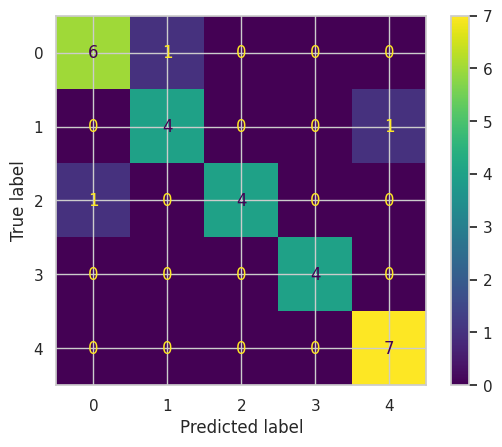

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Get model predictions (probabilities)
y_pred_probs = model_3.predict(X_val)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Predicted labels

# Generate classification report
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred_classes))

# Generate confusion matrix
print("Confusion Matrix:")
cnf_matrix =confusion_matrix(y_val_encoded, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix= cnf_matrix)
disp.plot();

**Model 4 : Improved MobileNetV2**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# Load pre-trained MobileNetV2 without the top classification layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the top 10 layers for fine-tuning
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Define the new model architecture
model_4 = Sequential([
    base_model,  # Pre-trained base model with some layers unfrozen
    GlobalAveragePooling2D(),  # Reduce the dimensionality of feature maps
    Dense(128, activation='relu'),  # Fully connected layer with ReLU activation
    Dropout(0.5),  # Dropout to prevent overfitting
    Dense(num_classes, activation='softmax')  # Output layer with softmax activation
])

# Compile the model with a lower learning rate for fine-tuning
model_4.compile(
    optimizer=SGD(learning_rate=0.0001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

# Convert to dictionary format required by Keras
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class Weights:", class_weights_dict)

# Define cosine annealing learning rate scheduler
def cosine_annealing(epoch, lr):
    return 0.0001 * (0.5 * (1 + np.cos(np.pi * (epoch % 10) / 10)))

lr_scheduler = LearningRateScheduler(cosine_annealing)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

# Convert dataset to `tf.data.Dataset` for optimized performance
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_augmented, y_train_augmented))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_encoded))
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# Train the model with class weights and fine-tuned layers
hist_4 = model_4.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weights_dict
)


Class Weights: {0: 0.76, 1: 1.2666666666666666, 2: 1.33, 3: 1.209090909090909, 4: 0.76}
Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 51s 577ms/step - accuracy: 0.2134 - loss: 2.1171 - val_accuracy: 0.2500 - val_loss: 1.6331 - learning_rate: 1.0000e-04
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.3388 - loss: 1.6278 - val_accuracy: 0.3214 - val_loss: 1.4994 - learning_rate: 9.7553e-05
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.4770 - loss: 1.3118 - val_accuracy: 0.3929 - val_loss: 1.3720 - learning_rate: 9.0451e-05
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.5711 - loss: 1.1317 - val_accuracy: 0.5000 - val_loss: 1.2823 - learning_rate: 7.9389e-05
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.6387 - loss: 0.9843 - val_accuracy: 0.5357 - val_loss: 1.2111 - learning_rate: 6.5451e-05
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.6654 - loss: 0.9151 - val_accuracy: 0.5714 - val_loss: 1.1588 - l

In [ ]:
test_loss, test_accuracy = model_4.evaluate(X_test, y_test_encoded)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7241 - loss: 0.6531
Test Loss: 0.6531
Test Accuracy: 0.7241


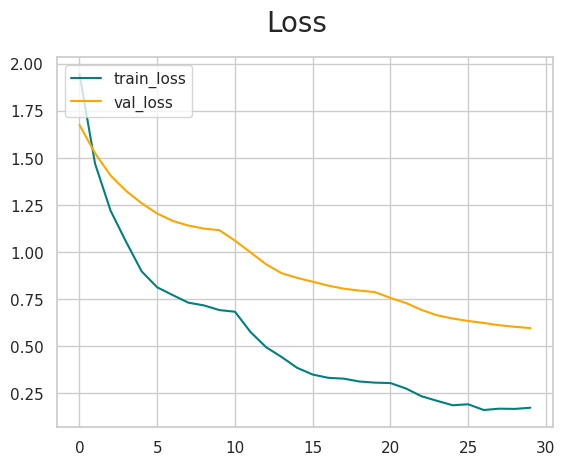

In [ ]:
#Plotting the training and validation loss
fig = plt.figure()
plt.plot(hist_4.history['loss'], color='teal', label='train_loss')
plt.plot(hist_4.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

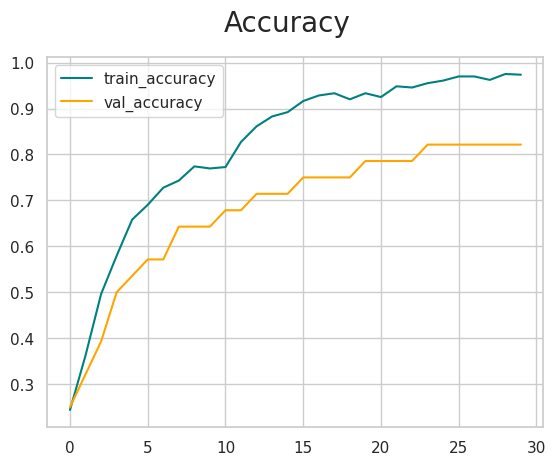

In [ ]:
#Plot the training and validation accuracy
fig = plt.figure()
plt.plot(hist_4.history['accuracy'], color='teal', label='train_accuracy')
plt.plot(hist_4.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.62      1.00      0.77         5
           2       0.80      0.80      0.80         5
           3       1.00      0.50      0.67         4
           4       1.00      1.00      1.00         7

    accuracy                           0.82        28
   macro avg       0.85      0.80      0.80        28
weighted avg       0.86      0.82      0.82        28

Confusion Matrix:


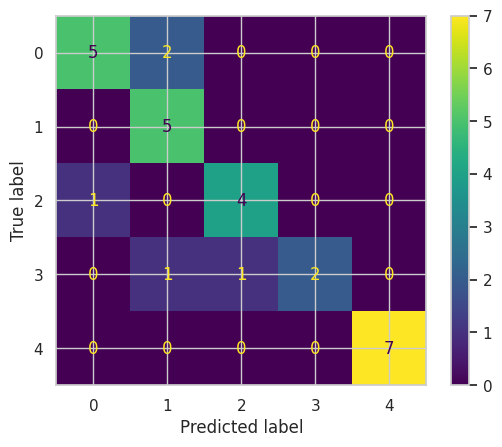

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Get model predictions (probabilities)
y_pred_probs = model_4.predict(X_val)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Predicted labels

# Generate classification report
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred_classes))

# Generate confusion matrix
print("Confusion Matrix:")
cnf_matrix =confusion_matrix(y_val_encoded, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix= cnf_matrix)
disp.plot();

**Model 5 : Further Improved MobileNetV2**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# Load MobileNetV2 with pre-trained ImageNet weights (excluding top layers)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze top layers for fine-tuning
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Define the new model architecture
model_5 = Sequential([
    base_model,  # Pre-trained base model
    GlobalAveragePooling2D(),  # Reduces dimensionality
    BatchNormalization(),  # Normalizes activations for stable training
    Dense(128, activation='relu'),  # Fully connected layer with ReLU activation
    Dropout(0.5),  # Dropout to prevent overfitting
    Dense(num_classes, activation='softmax')  # Output layer for classification
])

# Compile the model with Adam optimizer
model_5.compile(
    optimizer=Adam(learning_rate=0.0001),  # Fine-tuning requires a low learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class Weights:", class_weights_dict)

# Learning rate scheduler
def cosine_annealing(epoch, lr):
    return 0.0001 * (0.5 * (1 + np.cos(np.pi * (epoch % 10) / 10)))

lr_scheduler = LearningRateScheduler(cosine_annealing)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

# Convert dataset to `tf.data.Dataset` for optimized performance
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_augmented, y_train_augmented))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_encoded))
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# Train the model with class weights and fine-tuned layers
hist_5 = model_5.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weights_dict
)






Class Weights: {0: 0.76, 1: 1.2666666666666666, 2: 1.33, 3: 1.209090909090909, 4: 0.76}
Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 76s 724ms/step - accuracy: 0.4282 - loss: 1.6722 - val_accuracy: 0.5714 - val_loss: 1.0526 - learning_rate: 1.0000e-04
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.9100 - loss: 0.2327 - val_accuracy: 0.7143 - val_loss: 0.7401 - learning_rate: 9.7553e-05
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.9793 - loss: 0.0850 - val_accuracy: 0.7500 - val_loss: 0.6554 - learning_rate: 9.0451e-05
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.9897 - loss: 0.0470 - val_accuracy: 0.7500 - val_loss: 0.6201 - learning_rate: 7.9389e-05
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.9982 - loss: 0.0256 - val_accuracy: 0.7857 - val_loss: 0.5540 - learning_rate: 6.5451e-05
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.9967 - loss: 0.0203 - val_accuracy: 0.8214 - val_loss: 0.5183 - l

In [ ]:
# Evaluate on test set
test_loss, test_accuracy = model_5.evaluate(X_test, y_test_encoded)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8621 - loss: 0.3880
Test Loss: 0.3880
Test Accuracy: 0.8621


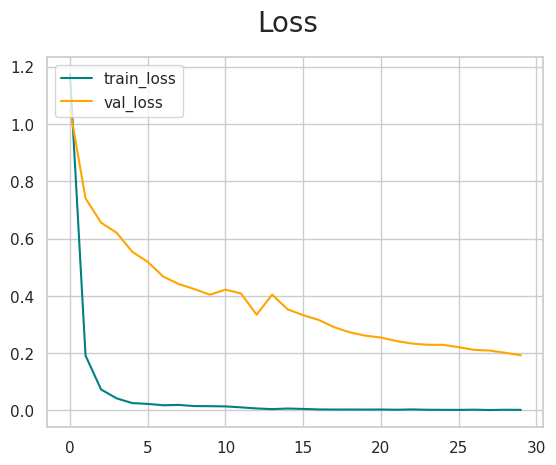

In [ ]:
#Plotting the training and validation loss
fig = plt.figure()
plt.plot(hist_5.history['loss'], color='teal', label='train_loss')
plt.plot(hist_5.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

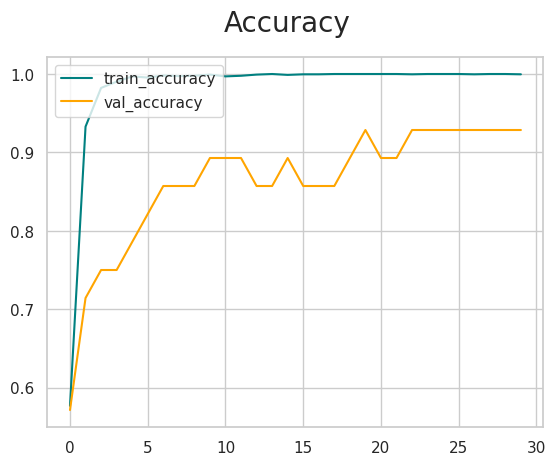

In [ ]:
#Plot the training and validation accuracy
fig = plt.figure()
plt.plot(hist_5.history['accuracy'], color='teal', label='train_accuracy')
plt.plot(hist_5.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.83      1.00      0.91         5
           2       1.00      1.00      1.00         5
           3       1.00      0.75      0.86         4
           4       0.88      1.00      0.93         7

    accuracy                           0.93        28
   macro avg       0.94      0.92      0.92        28
weighted avg       0.94      0.93      0.93        28

Confusion Matrix:


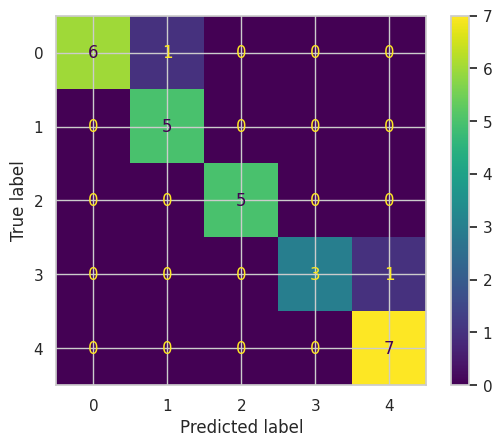

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Get model predictions (probabilities)
y_pred_probs = model_5.predict(X_val)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Predicted labels

# Generate classification report
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred_classes))

# Generate confusion matrix
print("Confusion Matrix:")
cnf_matrix =confusion_matrix(y_val_encoded, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix= cnf_matrix)
disp.plot();

**Model 6: EfficientNetV2**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Load EfficientNetV2 with pretrained ImageNet weights (without top layers)
base_model = EfficientNetV2S(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the last few layers for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Define the new model architecture
model_7 = Sequential([
    base_model,  # Pre-trained base model
    GlobalAveragePooling2D(),  # Reduces dimensionality
    BatchNormalization(),  # Normalizes activations for stability
    Dense(256, activation='relu'),  # Fully connected layer with ReLU activation
    Dropout(0.5),  # Dropout for regularization
    Dense(num_classes, activation='softmax')  # Output layer for classification
])

# Compile the model with Adam optimizer and a low learning rate
model_7.compile(
    optimizer=Adam(learning_rate=0.0001),  # Lower learning rate for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Compute class weights for handling imbalanced data
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3]
)

# Convert dataset to `tf.data.Dataset` for better performance
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_augmented, y_train_augmented))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val_encoded))
val_dataset = val_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# Train the model
hist_7 = model_7.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)




Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accuracy: 0.4187 - loss: 1.7044 - val_accuracy: 0.2143 - val_loss: 1.6328
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 27s 630ms/step - accuracy: 0.9234 - loss: 0.2170 - val_accuracy: 0.8929 - val_loss: 0.5462
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 596ms/step - accuracy: 0.9875 - loss: 0.0489 - val_accuracy: 0.9286 - val_loss: 0.2877
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 586ms/step - accuracy: 0.9944 - loss: 0.0246 - val_accuracy: 0.9286 - val_loss: 0.2187
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 601ms/step - accuracy: 0.9980 - loss: 0.0117 - val_accuracy: 0.9286 - val_loss: 0.1593
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 599ms/step - accuracy: 0.9986 - loss: 0.0131 - val_accuracy: 0.9286 - val_loss: 0.1820
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 597ms/step - accuracy: 0.9971 - loss: 0.0132 - val_accuracy: 0.9286 - val_loss: 0.1523
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 598ms/step - accuracy: 0.9995 - loss: 0.0051 - val_accura

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model_7.evaluate(X_test, y_test_encoded)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.8966 - loss: 0.2773
Test Loss: 0.2773
Test Accuracy: 0.8966


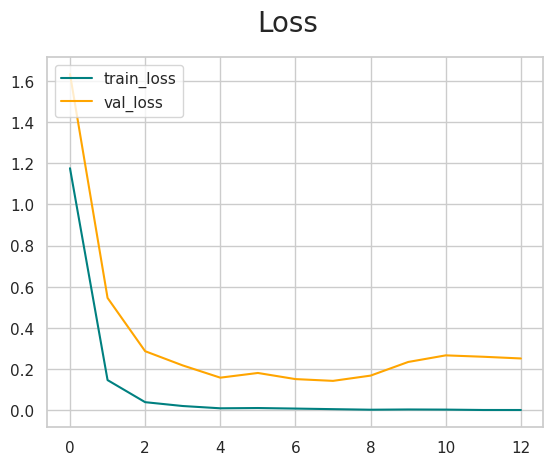

In [ ]:
#Plotting the training and validation loss
fig = plt.figure()
plt.plot(hist_7.history['loss'], color='teal', label='train_loss')
plt.plot(hist_7.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

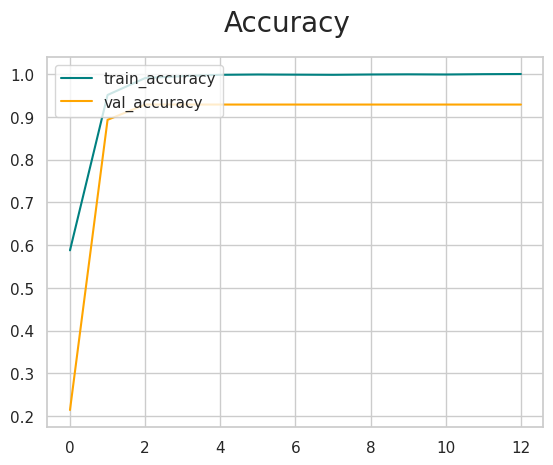

In [ ]:
#Plot the training and validation accuracy
fig = plt.figure()
plt.plot(hist_7.history['accuracy'], color='teal', label='train_accuracy')
plt.plot(hist_7.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.83      1.00      0.91         5
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         7

    accuracy                           0.93        28
   macro avg       0.94      0.93      0.93        28
weighted avg       0.93      0.93      0.93        28

Confusion Matrix:


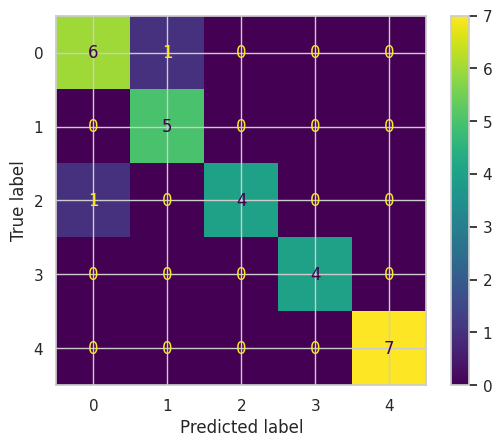

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# Get model predictions (probabilities)
y_pred_probs = model_7.predict(X_val)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Predicted labels

# Generate classification report
print("Classification Report:")
print(classification_report(y_val_encoded, y_pred_classes))

# Generate confusion matrix
print("Confusion Matrix:")
cnf_matrix =confusion_matrix(y_val_encoded, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix= cnf_matrix)
disp.plot();

In [ ]:
#Convert to html
!jupyter nbconvert --to html "/content/drive/MyDrive/Capstone_Project_group1/ Objective3_Capstone.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Project_group1/ Objective3_Capstone.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 26 image(s).
[NbConvertApp] Writing 3016323 bytes to /content/drive/MyDrive/Capstone_Project_group1/ Objective3_Capstone.html


In [ ]:
#Setting the shape of the test data
X_test = np.array(test_df["Image"].tolist())
X_test = X_test.reshape(-1, 224, 224, 3)
y_test =test_df["Category"]
y_test_encoded = label_encoder.fit_transform(y_test)#Setting the shape of the test data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


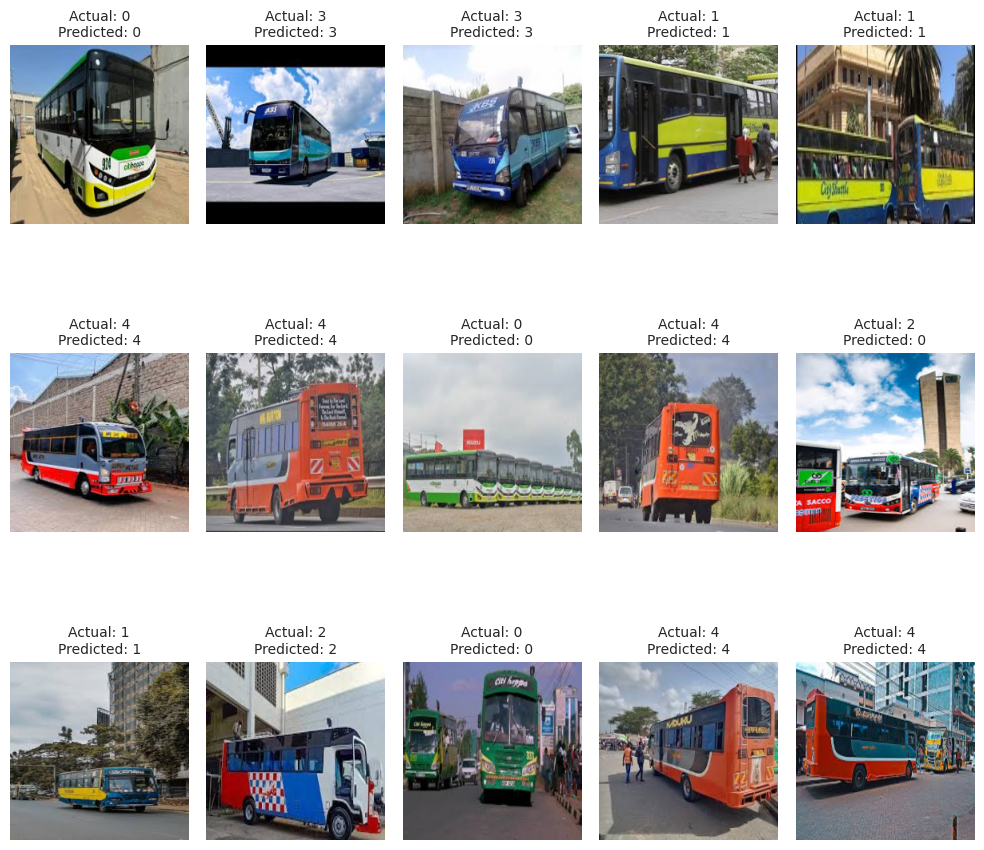

In [ ]:
# Get predictions
y_pred_probs = model_7.predict(X_val)  # Predict probabilities
y_pred_classes = np.argmax(y_pred_probs, axis=1)  # Convert to class labels

# Display a few images with predicted and actual labels
num_images = 15  # Number of images to display
plt.figure(figsize=(10, 10))

for i in range(num_images):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_val[i])  # Display image
    actual_label = y_val_encoded[i]  # True label
    predicted_label = y_pred_classes[i]  # Predicted label
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Save the best model for deployment**


In [ ]:
# Recommended way (Keras format)
model_7.save("model_7.keras")

**CONCLUSION**

The project successfully developed a classification system for various Public Service Vehicles (PSVs) by leveraging both custom CNN architectures and advanced transfer learning approaches. Despite challenges like limited and imbalanced data, variable image quality, and potential overfitting, careful data augmentation and hyperparameter tuning led to progressively improved models. The EfficientNet V2 model ultimately emerged as the best performer, achieving around 93% validation accuracy and demonstrating balanced precision and recall across all PSV categories.

**RECOMENDATIONS**


• Expand Dataset: Increasing the number of images (and covering more diverse scenarios) will help further reduce overfitting and improve model robustness.

• Refine Augmentation: Continue experimenting with targeted augmentation strategies (e.g., color, lighting, and viewpoint transformations) to enhance data diversity without losing essential bus features.

• Explore Advanced Architectures/Ensembles: Consider ensembling multiple high‐performing models or experimenting with other state‐of‐the‐art architectures to boost accuracy.

• Validate in Real‐World Settings: Conduct on‐site or real‐time tests to ensure the model generalizes well to new images, lighting conditions, and angles not covered in the training data.

• Monitor and Update: As new PSV designs or operator branding changes emerge, periodically retrain or fine‐tune the model to maintain high classification accuracy.






